In [1]:
import sys
sys.path.append('/home/simon/Work/morphometry')


import pandas as pd
import numpy as np
import nibabel as nib
import traceback
from pathlib import Path
from morphometry.femur import calculate_femoral_torsion
from morphometry.tibia import calculate_tibial_torsion
from morphometry.knee import calculate_knee_rotation_angle
from morphometry.whole_leg import calculate_mikulicz_deviation, calculate_bone_length
from morphometry.ankle import calculate_pma_angle
from morphometry.hip import calculate_ccd
from morphometry.image_io import Segmentation
from matplotlib import pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool

In [2]:
patient = 'PA000110'

hip = Segmentation('nibabel')
hip.read_image(f'/home/simon/Data/Augsburg_large/reader_study_augsburg/{patient}/hip_seg_test.nii.gz')
knee = Segmentation('nibabel')
knee.read_image(f'/home/simon/Data/Augsburg_large/reader_study_augsburg/{patient}/knee_seg_test.nii.gz')
ankle = Segmentation('nibabel')
ankle.read_image(f'/home/simon/Data/Augsburg_large/reader_study_augsburg/{patient}/ankle_seg_test.nii.gz')

In [3]:
hip.shape

(384, 324, 16)

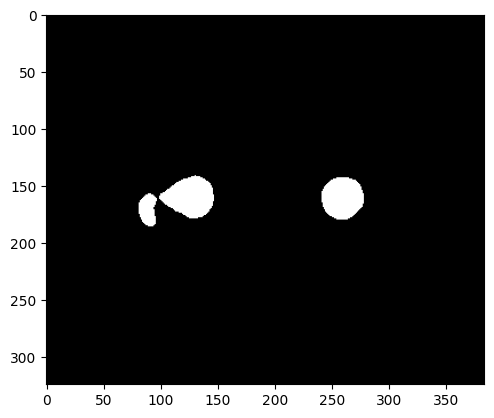

In [4]:
plt.imshow(hip.array[:, :, hip.array.shape[2] // 2].T, cmap='gray')

In [5]:
hip.transform_coordinate_system()
knee.transform_coordinate_system()
ankle.transform_coordinate_system()

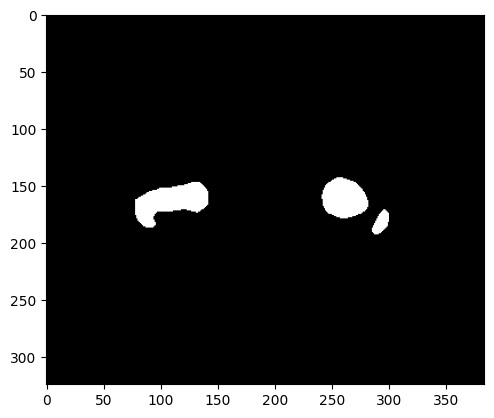

In [6]:
plt.imshow(hip.array[:, :, hip.array.shape[2] // 2].T, cmap='gray')

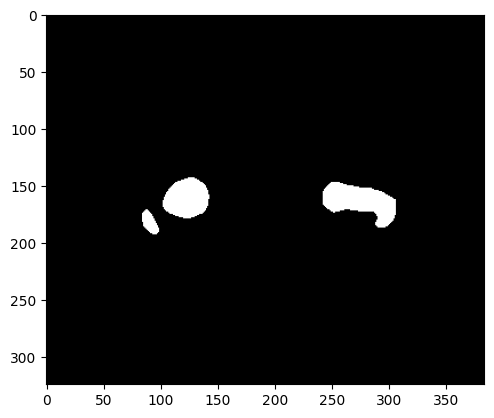

In [7]:
plt.imshow(np.flip(hip.array, axis=0)[:, :, hip.array.shape[2] // 2].T, cmap='gray')

In [8]:
hip.remove_outliers()
knee.remove_outliers()
ankle.remove_outliers()

In [9]:
x_ratio = abs(hip.spacing[2]) / 2 * abs(hip.spacing[0])

In [10]:
hip_mask = hip.array
knee_mask = knee.array
ankle_mask = ankle.array

left_hip = hip_mask[:hip_mask.shape[0] // 2]
right_hip = hip_mask[hip_mask.shape[0] // 2:]
left_knee = knee_mask[:knee_mask.shape[0] // 2]
right_knee = knee_mask[knee_mask.shape[0] // 2:]
left_ankle = ankle_mask[:ankle_mask.shape[0] // 2]
right_ankle = ankle_mask[ankle_mask.shape[0] // 2:]

left_hip = nib.Nifti1Image(left_hip, hip.affine, hip.header)
left_hip = Segmentation.from_nibabel(left_hip)
right_hip = nib.Nifti1Image(right_hip, hip.affine, hip.header)
right_hip = Segmentation.from_nibabel(right_hip)
left_knee = nib.Nifti1Image(left_knee, knee.affine, knee.header)
left_knee = Segmentation.from_nibabel(left_knee)
right_knee = nib.Nifti1Image(right_knee, knee.affine, knee.header)
right_knee = Segmentation.from_nibabel(right_knee)
left_ankle = nib.Nifti1Image(left_ankle, ankle.affine, ankle.header)
left_ankle = Segmentation.from_nibabel(left_ankle)
right_ankle = nib.Nifti1Image(right_ankle, ankle.affine, ankle.header)
right_ankle = Segmentation.from_nibabel(right_ankle)

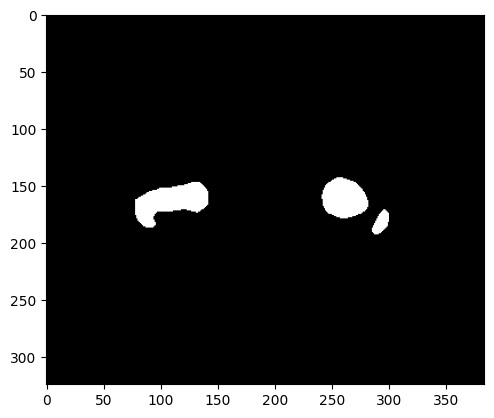

In [11]:
plt.imshow(hip_mask[:, :, hip_mask.shape[2] // 2].T, cmap='gray')

In [12]:
left_hip.shape

(192, 324, 16)

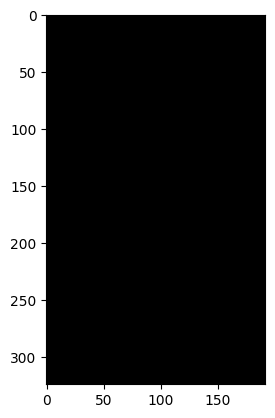

In [13]:
plt.imshow(left_hip.array[:, :, 1].T, cmap='gray')

In [14]:
left_knee.shape

(192, 324, 34)

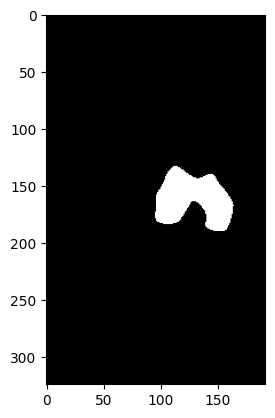

In [15]:
plt.imshow(left_knee.array[:, :, 13].T, cmap='gray')

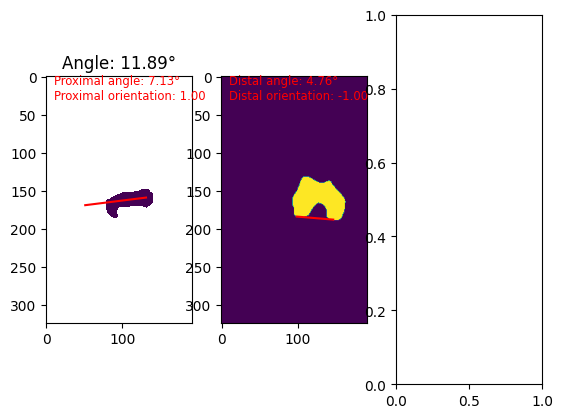

In [16]:
at_lee_left, fig = calculate_femoral_torsion(left_hip, left_knee.array, side='left', x_ratio=x_ratio, plot=True)

In [24]:
x = False
y = True
z = True
if x and (y or z):
    print(x, y, z)